# Profile likelihood for discrete-time LTI: KF vs EnKF vs EKF vs UKF vs PF

This **deep dive** builds a **profile likelihood** and **profile score** for a single parameter (one entry of the $A$ matrix) in a discrete-time LTI system. All other parameters are **known** (no biases). Controls are simulated i.i.d. from $\mathcal{N}(0,1)$. We compare the profile log-likelihood computed with:

- **KF** (exact Kalman filter, cuthbert & dynamax)
- **EnKF** (ensemble Kalman filter, cuthbert)
- **EKF** (Taylor-linearized Kalman filter, cuthbert & dynamax)
- **UKF** (Sigma-point Kalman filter, dynamax)
- **PF** (bootstrap particle filter, cuthbert)

**Setup:** 2 states, 1 control, 1 output. We learn $\alpha = A_{0,0}$; $A_{1,1}$ and $B$, $H$, $R$, $Q$ are fixed.

## Imports and config

In [1]:
import time

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import (
    DiscreteTimeSimulator,
    DynamicalModel,
    Filter,
    LinearGaussianObservation,
    LinearGaussianStateEvolution,
)
from dynestyx.inference.filters import EKFConfig, EnKFConfig, KFConfig, PFConfig, UKFConfig

# Dimensions: 2 states, 1 control, 1 output
state_dim = 2
control_dim = 1
observation_dim = 1

## LTI model: one learned parameter $\alpha = A_{0,0}$, no biases

We set $A = \begin{bmatrix} \alpha & 0 \\ 0 & 0.8 \end{bmatrix}$, $B$, $H$, $R$, $Q$ fixed. Biases $b$, $d$ are zero.

In [2]:
def lti_one_param_model(obs_times=None, obs_values=None, ctrl_times=None, ctrl_values=None, predict_times=None):
    """Discrete-time LTI: only alpha = A[0,0] is sampled; all else fixed, no biases."""
    alpha = numpyro.sample("alpha", dist.Uniform(-0.7, 0.7))
    A = jnp.array([[alpha, 0.0], [0.0, 0.8]])
    Q = 0.1 * jnp.eye(state_dim)
    H = jnp.array([[1.0, 0.0]])
    R = jnp.array([[0.5**2]])
    initial_mean = jnp.zeros(state_dim)
    initial_cov = jnp.eye(state_dim)
    B = jnp.array([[0.1], [0.0]])
    D = jnp.array([[0.01]])
    # No biases
    b = jnp.zeros(state_dim)
    d = jnp.zeros(observation_dim)
    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(initial_mean, initial_cov),
        state_evolution=LinearGaussianStateEvolution(A=A, B=B, bias=b, cov=Q),
        observation_model=LinearGaussianObservation(H=H, D=D, bias=d, R=R),
        control_dim=control_dim,
    )
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
        predict_times=predict_times,
    )

## True parameter, observation times, and controls $u_t \sim \mathcal{N}(0,1)$

In [3]:
true_alpha = 0.4
obs_times = jnp.arange(0.0, 1000.0, 1.0)
T = len(obs_times)

key = jr.PRNGKey(42)
key_ctrl, key_data = jr.split(key)
# Controls i.i.d. N(0,1)
ctrl_values = jr.normal(key_ctrl, shape=(T, control_dim))
ctrl_times = obs_times  # same times for controls

print("True alpha:", true_alpha)
print("Observation times length:", T)
print("Controls shape:", ctrl_values.shape)

True alpha: 0.4
Observation times length: 1000
Controls shape: (1000, 1)


## Generate synthetic observations

Simulate the model with true $\alpha$ and the control trajectory to get $y_{1:T}$.

In [4]:
predictive = Predictive(
    lti_one_param_model,
    params={"alpha": jnp.array(true_alpha)},
    num_samples=1,
    exclude_deterministic=False,
)

with DiscreteTimeSimulator():
    synthetic = predictive(key_data, predict_times=obs_times, ctrl_times=ctrl_times, ctrl_values=ctrl_values)

# f_observations: (num_samples, n_sim, T, obs_dim)
obs_values = synthetic["f_observations"][0, 0]
print("Observations shape:", obs_values.shape)

Observations shape: (1000, 1)


## Profile log-likelihood

For each filter type (KF, EKF, UKF, PF), we compute $\log p(y_{1:T} \mid \alpha)$ by running `Predictive` with `params={"alpha": alpha}`. The marginal log-likelihood is the `f_marginal_loglik` deterministic site. We `vmap` over the grid of $\alpha$ values.

**Note:** The EnKF and PF profiles are stochastic approximations. `EnKFConfig()` uses a fixed common-random-number seed by default, so its profile is reproducible unless you set `crn_seed=None`; re-run the PF cell with a different key to see variability. KF, EKF, and UKF are deterministic for this LTI model.

In [5]:
alpha_min, alpha_max = -0.6, 0.6
n_grid = 61
alpha_grid = jnp.linspace(alpha_min, alpha_max, n_grid)


def make_model(filter_type, filter_source):
    """Build data-conditioned model with given filter type."""
    config = {
        "kf": KFConfig(filter_source=filter_source),
        "enkf": EnKFConfig(n_particles=100, filter_source=filter_source),
        "pf": PFConfig(n_particles=1_000, filter_source=filter_source),
        "ekf": EKFConfig(filter_source=filter_source),
        "ukf": UKFConfig(filter_source=filter_source),
    }[filter_type]

    def model():
        with Filter(filter_config=config):
            return lti_one_param_model(obs_times=obs_times, obs_values=obs_values, ctrl_times=ctrl_times, ctrl_values=ctrl_values)

    return model


def get_marginal_loglik(alpha_val, key, filter_type, filter_source):
    """Run Predictive with fixed alpha; return f_marginal_loglik site."""
    model = make_model(filter_type, filter_source)
    pred = Predictive(
        model,
        params={"alpha": jnp.array(alpha_val)},
        num_samples=1,
        exclude_deterministic=False,
    )
    out = pred(key)
    return out["f_marginal_loglik"].squeeze()


def profile_log_likelihood(filter_type, filter_source, alpha_vals, key=jr.PRNGKey(0)):
    """Profile log p(y | alpha) via vmap over Predictive + f_marginal_loglik. Returns (profile_array, time_seconds)."""
    keys = jr.split(key, len(alpha_vals))
    t0 = time.perf_counter()
    profile = jax.vmap(
        lambda a, k: get_marginal_loglik(a, k, filter_type, filter_source),
        in_axes=(0, 0),
    )(alpha_vals, keys)
    elapsed = time.perf_counter() - t0
    return profile, elapsed

In [6]:
profile_kf_cb, t_kf_cb = profile_log_likelihood("kf", "cuthbert", alpha_grid)
profile_kf_dynamax, t_kf_dynamax = profile_log_likelihood("kf", "cd_dynamax", alpha_grid)

profile_ekf_cb, t_ekf_cb = profile_log_likelihood("ekf", "cuthbert", alpha_grid)
profile_ekf_dynamax, t_ekf_dynamax = profile_log_likelihood("ekf", "cd_dynamax", alpha_grid)

profile_enkf_cb, t_enkf_cb = profile_log_likelihood("enkf", "cuthbert", alpha_grid)

profile_ukf_dynamax, t_ukf_dynamax = profile_log_likelihood("ukf", "cd_dynamax", alpha_grid)

profile_pf_cb, t_pf_cb = profile_log_likelihood("pf", "cuthbert", alpha_grid)

timings = {"KF (Cuthbert)": t_kf_cb, "KF (Dynamax)": t_kf_dynamax, "EKF (Cuthbert)": t_ekf_cb, "EKF (Dynamax)": t_ekf_dynamax, "EnKF (Cuthbert)": t_enkf_cb, "UKF (Dynamax)": t_ukf_dynamax, "PF (Cuthbert)": t_pf_cb}
profiles = {
    "KF (Cuthbert)": profile_kf_cb,
    "KF (Dynamax)": profile_kf_dynamax,
    "EKF (Cuthbert)": profile_ekf_cb,
    "EKF (Dynamax)": profile_ekf_dynamax,
    "EnKF (Cuthbert)": profile_enkf_cb,
    "UKF (Dynamax)": profile_ukf_dynamax,
    "PF (Cuthbert)": profile_pf_cb,
}

print("Filter      | max profile ll  | time (s)")
print("------------|-----------------|--------")
for name in timings.keys():
    ll = float(jnp.nanmax(profiles[name]))
    print(f"{name:11} | {ll:15.4f} | {timings[name]:.3f}")

Filter      | max profile ll  | time (s)
------------|-----------------|--------
KF (Cuthbert) |       -912.7115 | 1.723
KF (Dynamax) |       -912.7115 | 0.843
EKF (Cuthbert) |       -912.7115 | 2.028
EKF (Dynamax) |       -912.7115 | 0.684
EnKF (Cuthbert) |       -916.0390 | 1.333
UKF (Dynamax) |       -912.7115 | 0.717
PF (Cuthbert) |       -912.7143 | 7.158


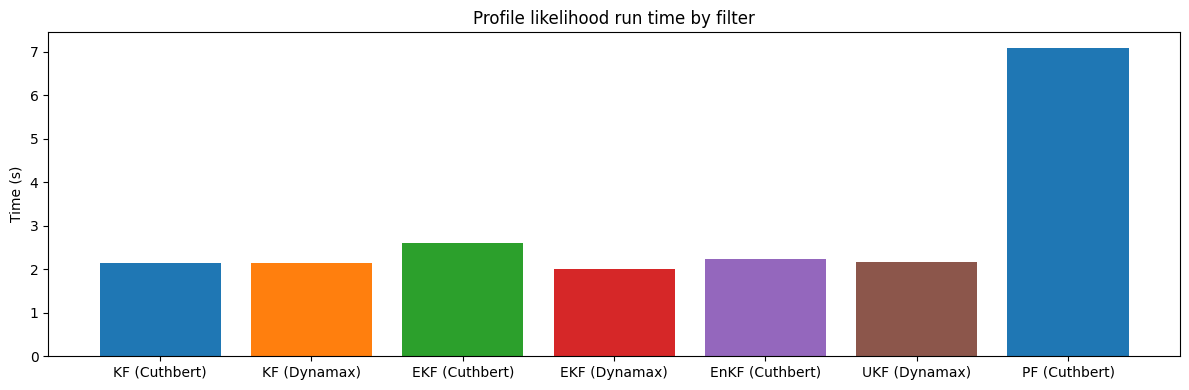

In [15]:
# Bar chart of profile likelihood run times
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
names = list(timings.keys())
times = [timings[n] for n in names]
ax.bar(names, times, color=["C0", "C1", "C2", "C3", "C4", "C5"])
ax.set_ylabel("Time (s)")
ax.set_title("Profile likelihood run time by filter")
plt.tight_layout()
plt.show()

## Plot profile log-likelihoods

All filters should peak near the true $\alpha = 0.4$. KF is exact for this LTI; EKF and UKF are Gaussian approximations; EnKF and PF are Monte Carlo approximations.

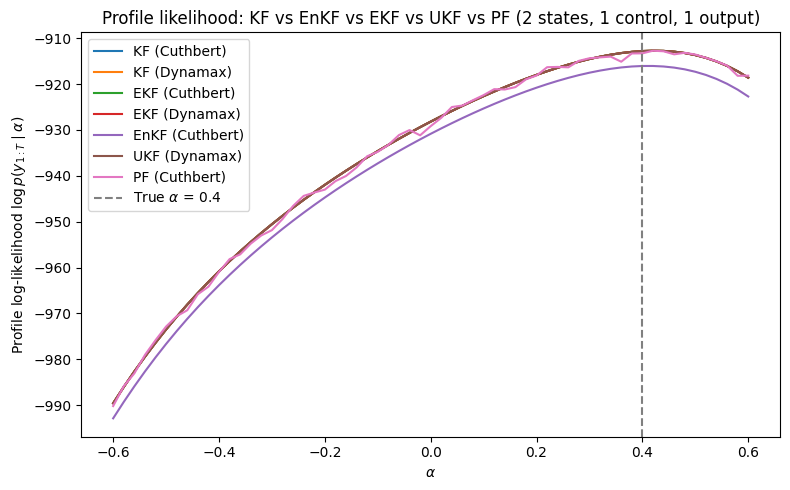

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(np.array(alpha_grid), np.array(profile_kf_cb), label="KF (Cuthbert)", color="C0")
ax.plot(np.array(alpha_grid), np.array(profile_kf_dynamax), label="KF (Dynamax)", color="C1")
ax.plot(np.array(alpha_grid), np.array(profile_ekf_cb), label="EKF (Cuthbert)", color="C2")
ax.plot(np.array(alpha_grid), np.array(profile_ekf_dynamax), label="EKF (Dynamax)", color="C3")
ax.plot(np.array(alpha_grid), np.array(profile_enkf_cb), label="EnKF (Cuthbert)", color="C4")
ax.plot(np.array(alpha_grid), np.array(profile_ukf_dynamax), label="UKF (Dynamax)", color="C5")
ax.plot(np.array(alpha_grid), np.array(profile_pf_cb), label="PF (Cuthbert)", color="C6")
ax.axvline(
    true_alpha, color="gray", linestyle="--", label=f"True $\\alpha$ = {true_alpha}"
)
ax.set_xlabel("$\\alpha$")
ax.set_ylabel("Profile log-likelihood $\\log p(y_{1:T} \\mid \\alpha)$")
ax.legend()
ax.set_title(
    "Profile likelihood: KF vs EnKF vs EKF vs UKF vs PF (2 states, 1 control, 1 output)"
)
plt.tight_layout()
plt.show()

## Profile Score

For each filter type (KF, EnKF, EKF, UKF, PF), we can also compute $\nabla_\alpha \log p(y_{1:T} \mid \alpha)$ with direct auto-differentiation.

In [9]:
def profile_score(filter_type, filter_source, alpha_vals, key=jr.PRNGKey(0)):
    """Profile log p(y | alpha) via vmap over Predictive + f_marginal_loglik. Returns (profile_array, time_seconds)."""
    keys = jr.split(key, len(alpha_vals))
    t0 = time.perf_counter()
    get_score = jax.jit(
        lambda a, k: jax.grad(get_marginal_loglik)(a, k, filter_type, filter_source)
    )
    profile = jax.vmap(
        lambda a, k: get_score(a, k),
        in_axes=(0, 0),
    )(alpha_vals, keys)
    elapsed = time.perf_counter() - t0
    return profile, elapsed

In [10]:
profile_kf_cb, t_kf_cb = profile_score("kf", "cuthbert", alpha_grid)
profile_kf_dynamax, t_kf_dynamax = profile_score("kf", "cd_dynamax", alpha_grid)

profile_ekf_cb, t_ekf_cb = profile_score("ekf", "cuthbert", alpha_grid)
profile_ekf_dynamax, t_ekf_dynamax = profile_score("ekf", "cd_dynamax", alpha_grid)

profile_enkf_cb, t_enkf_cb = profile_score("enkf", "cuthbert", alpha_grid)

profile_ukf_dynamax, t_ukf_dynamax = profile_score("ukf", "cd_dynamax", alpha_grid)

profile_pf_cb, t_pf_cb = profile_score("pf", "cuthbert", alpha_grid)

timings = {"KF (Cuthbert)": t_kf_cb, "KF (Dynamax)": t_kf_dynamax, "EKF (Cuthbert)": t_ekf_cb, "EKF (Dynamax)": t_ekf_dynamax, "EnKF (Cuthbert)": t_enkf_cb, "UKF (Dynamax)": t_ukf_dynamax, "PF (Cuthbert)": t_pf_cb}
profiles = {
    "KF (Cuthbert)": profile_kf_cb,
    "KF (Dynamax)": profile_kf_dynamax,
    "EKF (Cuthbert)": profile_ekf_cb,
    "EKF (Dynamax)": profile_ekf_dynamax,
    "EnKF (Cuthbert)": profile_enkf_cb,
    "UKF (Dynamax)": profile_ukf_dynamax,
    "PF (Cuthbert)": profile_pf_cb,
}

print("Filter      | max score       | time (s)")
print("------------|-----------------|--------")
for name in timings.keys():
    ll = float(jnp.nanmax(profiles[name]))
    print(f"{name:11} | {ll:15.4f} | {timings[name]:.3f}")

Filter      | max score       | time (s)
------------|-----------------|--------
KF (Cuthbert) |        182.1674 | 2.147
KF (Dynamax) |        182.1674 | 2.152
EKF (Cuthbert) |        182.1674 | 2.614
EKF (Dynamax) |        182.1674 | 2.008
EnKF (Cuthbert) |        183.2659 | 2.245
UKF (Dynamax) |        182.1674 | 2.160
PF (Cuthbert) |        201.7599 | 7.097


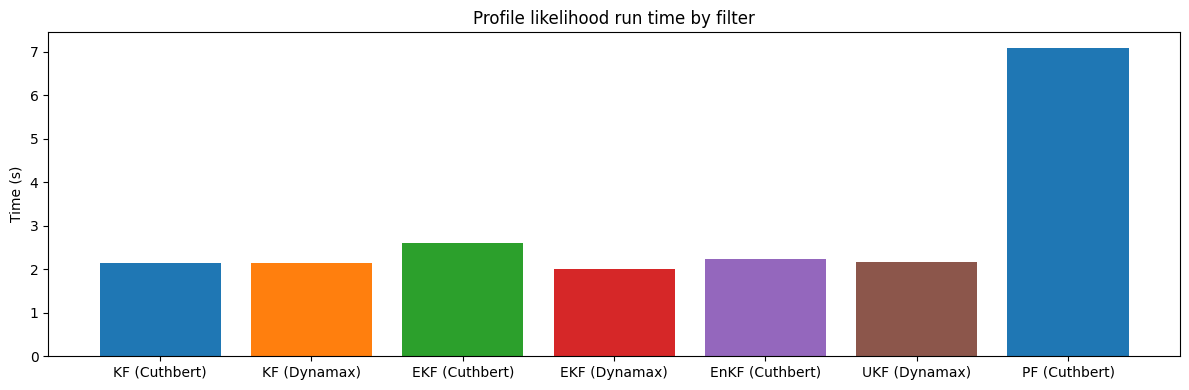

In [ ]:
# Bar chart of profile likelihood run times
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
names = list(timings.keys())
times = [timings[n] for n in names]
ax.bar(names, times, color=["C0", "C1", "C2", "C3", "C4", "C5"])
ax.set_ylabel("Time (s)")
ax.set_title("Profile likelihood run time by filter")
plt.tight_layout()
plt.show()

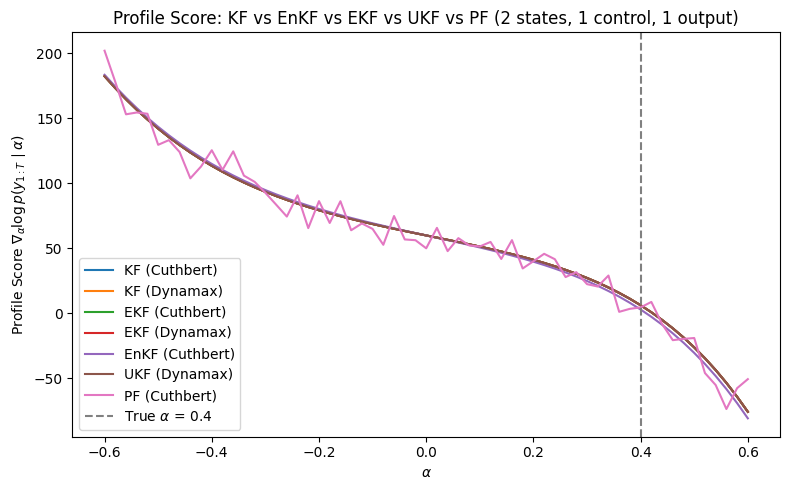

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(np.array(alpha_grid), np.array(profile_kf_cb), label="KF (Cuthbert)", color="C0")
ax.plot(np.array(alpha_grid), np.array(profile_kf_dynamax), label="KF (Dynamax)", color="C1")
ax.plot(np.array(alpha_grid), np.array(profile_ekf_cb), label="EKF (Cuthbert)", color="C2")
ax.plot(np.array(alpha_grid), np.array(profile_ekf_dynamax), label="EKF (Dynamax)", color="C3")
ax.plot(np.array(alpha_grid), np.array(profile_enkf_cb), label="EnKF (Cuthbert)", color="C4")
ax.plot(np.array(alpha_grid), np.array(profile_ukf_dynamax), label="UKF (Dynamax)", color="C5")
ax.plot(np.array(alpha_grid), np.array(profile_pf_cb), label="PF (Cuthbert)", color="C6")
ax.axvline(
    true_alpha, color="gray", linestyle="--", label=f"True $\\alpha$ = {true_alpha}"
)
ax.set_xlabel("$\\alpha$")
ax.set_ylabel("Profile Score $\\nabla_\\alpha \\log p(y_{1:T} \\mid \\alpha)$")
ax.legend()
ax.set_title(
    "Profile Score: KF vs EnKF vs EKF vs UKF vs PF (2 states, 1 control, 1 output)"
)
plt.tight_layout()
plt.show()